In [1]:
!pip install opencv-python pixellib

In [2]:
import cv2
import numpy as np
import torch
import torchvision.transforms as T
from torchvision.models.segmentation import deeplabv3_resnet101
import matplotlib.pyplot as plt

print(cv2.__version__)

4.13.0


원본 고양이 이미지 크기: (183, 275, 3)
배경(사막) 이미지 크기: (194, 259, 3)


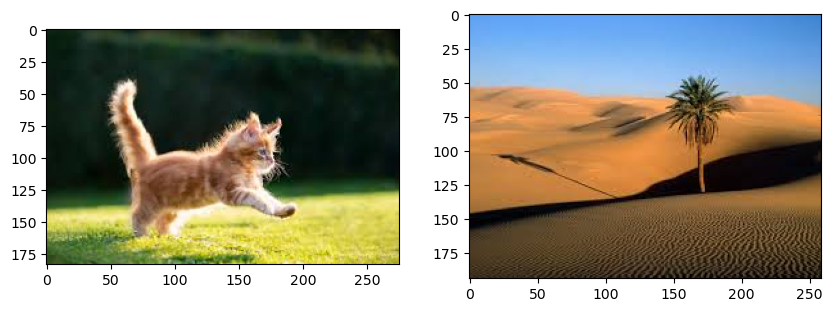

In [7]:
cat_img_path = "./images/cat.jpeg"  # 고양이 이미지를 준비해주세요
sand_img_path = "./images/sand.jpeg"  # 사막 배경 이미지를 준비해주세요

cat_img = cv2.imread(cat_img_path)
sand_img = cv2.imread(sand_img_path)

cat_img = cv2.cvtColor(cat_img, cv2.COLOR_BGR2RGB)
sand_img = cv2.cvtColor(sand_img, cv2.COLOR_BGR2RGB)

print(f"원본 고양이 이미지 크기: {cat_img.shape}")
print(f"배경(사막) 이미지 크기: {sand_img.shape}")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(cat_img)

plt.subplot(1, 2, 2)
plt.imshow(sand_img)

plt.show()

In [10]:
model = deeplabv3_resnet101(pretrained=True).eval()

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((520, 520)),  # 모델 입력 크기
    T.ToTensor(),
])

input_tensor = transform(cat_img).unsqueeze(0)

with torch.no_grad():
    output = model(input_tensor)["out"][0]
    output_predictions = output.argmax(0).byte().cpu().numpy()

print(f"추론 마스크 크기 (Before Resize): {output_predictions.shape}")

추론 마스크 크기 (Before Resize): (520, 520)


In [11]:
# 마스크를 원본 크기로 Resize
output_predictions_resized = cv2.resize(output_predictions, (cat_img.shape[1], cat_img.shape[0]), interpolation=cv2.INTER_NEAREST)

print(f"추론 마스크 크기 (After Resize): {output_predictions_resized.shape}")

추론 마스크 크기 (After Resize): (183, 275)


In [12]:
unique_classes = np.unique(output_predictions_resized)
print(f"예측된 클래스 ID: {unique_classes}")

예측된 클래스 ID: [0 8]


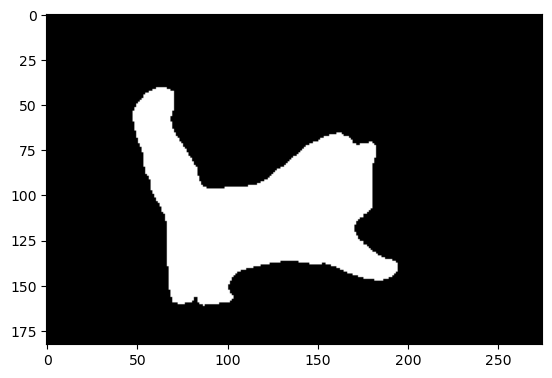

In [13]:
target_class_id = unique_classes[-1]

seg_map = (output_predictions_resized == target_class_id)
img_mask = seg_map.astype(np.uint8) * 255

plt.imshow(img_mask, cmap='gray')
plt.show()

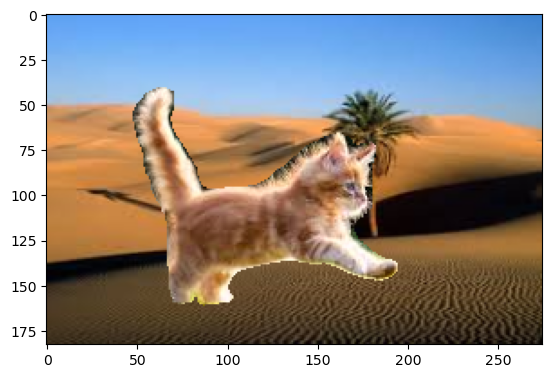

In [14]:
# 배경을 고양이 이미지 크기에 맞춤
sand_img_resized = cv2.resize(sand_img, (cat_img.shape[1], cat_img.shape[0]))

# 고양이 부분만 남기고 배경 적용
img_mask_color = cv2.cvtColor(img_mask, cv2.COLOR_GRAY2BGR)  # 3채널 변환
result_img = np.where(img_mask_color == 255, cat_img, sand_img_resized)  # 마스크 기반 합성

plt.imshow(result_img)
plt.show()

## Step 2. 사진에서 문제점 찾기

업로드된 노트북에서 생성한 고양이 배경 전환 결과를 기준으로 문제점을 표시했습니다. 핵심 원인은 DeepLabV3 semantic segmentation mask가 객체의 실제 경계를 완벽하게 따라가지 못하고, 2D 클래스 마스크만으로 전경/배경을 나누기 때문입니다.

### 발견한 문제점

1. **객체 가장자리 halo / 흰색 테두리 발생**  
   고양이 털 주변에 원본 배경 또는 보간 과정에서 생긴 밝은 테두리가 남아 있습니다. 특히 꼬리, 등, 얼굴 주변에서 경계가 자연스럽지 않습니다.

2. **얇은 털·발·배 부분의 마스크 누락**  
   고양이의 발과 배 아래쪽 일부가 정확히 분리되지 않아 잘려 보이거나 배경과 섞입니다. Semantic segmentation은 픽셀 단위 클래스 예측이므로 얇은 구조, 반투명 털, 작은 돌출부에서 오류가 커집니다.

3. **귀와 얼굴 주변 경계 번짐**  
   귀, 수염, 얼굴 윤곽처럼 세밀한 영역은 클래스 확률이 낮거나 주변 배경과 혼동되어 경계가 거칠게 나타납니다.

4. **깊이감/그림자 불일치**  
   합성된 사막 배경과 고양이의 조명, 그림자, 거리감이 맞지 않습니다. 단순 segmentation mask 기반 합성은 실제 피사계심도나 광학적 초점 거리를 고려하지 못합니다.

![문제점 표시 이미지](cat_portrait_mode_issues_marked.png)


In [ ]:
from IPython.display import Image, display

# Step 2 결과: 문제점 표시 이미지
display(Image(filename="cat_portrait_mode_issues_marked.png"))


## Step 3. 해결 방법 제안

### 제안 솔루션: Semantic Segmentation Mask + Depth Estimation + Matting Refinement 결합

현재 결과의 문제는 DeepLabV3가 만든 mask를 그대로 전경/배경 분리에 사용했기 때문에 발생했습니다. DeepLab의 semantic segmentation은 “고양이인지 아닌지”를 클래스 단위로 판단하지만, 실제 인물 모드나 보케 효과는 객체 클래스가 아니라 **카메라와 피사체 사이의 거리, 즉 depth**에 의해 결정됩니다. 따라서 mask 하나만으로 배경을 blur하거나 교체하면 경계 오류, halo, 얇은 털 누락, 깊이감 불일치가 생깁니다.

이를 개선하기 위해 다음과 같은 후처리 파이프라인을 제안합니다.

```text
입력 이미지
   │
   ├─ DeepLabV3 semantic segmentation → 1차 전경 mask
   │
   ├─ Depth estimation model → 픽셀별 상대 깊이 map
   │
   ├─ Edge detection / guided filter → 경계 보정
   │
   ├─ Image matting → alpha matte 생성
   │
   ├─ Depth-aware blur 또는 배경 합성
   │
   └─ 색상/조명/그림자 보정 → 최종 인물 모드 이미지
```

### 1. DeepLab mask를 그대로 쓰지 않고 확률 mask로 활용

현재 노트북에서는 `argmax`로 클래스 ID를 결정한 뒤 0 또는 255의 이진 mask를 만들었습니다. 이 방식은 경계 픽셀에서 정보 손실이 큽니다. 개선안에서는 DeepLab의 출력 logits 또는 softmax probability를 사용해 각 픽셀이 전경일 확률을 보존합니다. 예를 들어 고양이 클래스 확률이 0.51인 픽셀과 0.99인 픽셀을 동일하게 전경으로 처리하지 않고, 경계부는 불확실 영역으로 분리합니다.

### 2. Trimap 생성 후 image matting 적용

DeepLab mask에서 확실한 전경, 확실한 배경, 판단이 어려운 경계 영역을 나누어 trimap을 만듭니다. 예를 들어 mask를 erosion한 영역은 확실한 전경, dilation 바깥은 확실한 배경, 그 사이는 unknown 영역으로 둡니다. 이후 closed-form matting, MODNet, U²-Net 계열 matting 모델 등을 적용해 0~1 사이의 alpha matte를 생성합니다. 이렇게 하면 털, 머리카락, 수염처럼 얇고 반투명한 구조가 이진 mask보다 자연스럽게 합성됩니다.

### 3. Depth map으로 blur 강도를 다르게 적용

인물 모드의 핵심은 전경/배경의 단순 분리가 아니라 거리별 흐림입니다. MiDaS, DPT, ZoeDepth 같은 단안 depth estimation 모델을 사용하면 이미지 한 장에서도 상대적인 깊이 map을 추정할 수 있습니다. DeepLab mask가 피사체 후보를 알려주고, depth map은 어느 픀이 초점 거리에서 얼마나 떨어져 있는지 알려줍니다. 이후 초점 대상과 비슷한 depth를 가진 영역은 선명하게 유지하고, 더 멀거나 가까운 영역에는 거리 차이에 비례해 Gaussian blur 또는 lens blur를 적용합니다.

### 4. 경계 보정: guided filter와 CRF 활용

DeepLab 결과는 520×520 입력으로 resize되므로 원본으로 되돌릴 때 경계가 계단처럼 보일 수 있습니다. 이를 줄이기 위해 원본 RGB 이미지를 guide로 사용하는 guided filter를 적용합니다. 또한 DenseCRF를 사용하면 색상과 위치가 유사한 픽셀끼리 같은 label을 갖도록 유도할 수 있어, 객체 경계가 실제 이미지의 edge에 더 잘 맞게 조정됩니다.

### 5. 합성 후 색상·그림자 보정

배경을 바꾸는 경우에는 mask만 좋아도 합성 티가 날 수 있습니다. 전경 객체의 색온도와 배경의 색온도가 다르면 어색하고, 바닥 접점에 그림자가 없으면 물체가 떠 보입니다. 따라서 합성 후에는 배경의 평균 밝기와 색온도에 맞추어 전경 색상을 보정하고, 객체 하단에는 soft shadow를 추가합니다. 이 과정은 segmentation 오류를 직접 고치는 것은 아니지만 최종 결과의 자연스러움을 크게 높입니다.

### 최종 제안 요약

단순한 해결책은 “더 좋은 segmentation 모델을 사용한다”가 아니라, DeepLab mask를 1차 후보로만 사용하고 depth estimation, matting, edge-aware filtering을 결합하는 것입니다. DeepLab mask는 객체의 대략적인 위치를 제공하고, depth map은 실제 피사계심도 효과를 만들며, matting은 털·머리카락 같은 세밀한 경계를 부드럽게 복원합니다. 이 구조를 적용하면 옷, 머리카락, 동물 털, 배경 물체가 잘못 전경으로 남는 문제를 줄이고, 소비자가 보기에 더 자연스러운 인물 모드 사진을 만들 수 있습니다.


## 표시 이미지 첨부본

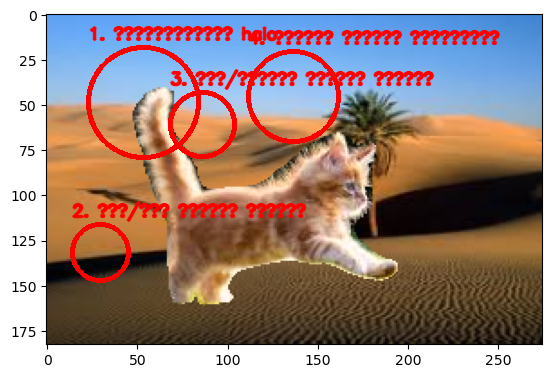